In [1]:
%load_ext autoreload
%autoreload 2

## Paso 1: Leer el archivo y aislar el campo del CSI


In [2]:
import os
# ir a la raíz del proyecto de forma idempotente (aunque ejecutes la celda varias veces)
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("estoy en:", os.getcwd())


estoy en: c:\Users\Marc\Desktop\Sensing


## Paso 2: Convertir el texto en amplitudes
Ahora transformamos cada fila de texto (128 enteros) en 64 amplitudes (una por subportadora).

In [3]:
from src.load_esp32 import load_esp32_csv, fila_a_amplitud

filas = load_esp32_csv("data/example_csi.csv")
amp0 = fila_a_amplitud(filas[0])
print("nº subportadoras:", len(amp0))
print("amplitudes:", amp0.round(1))

nº subportadoras: 64
amplitudes: [111.8   5.    0.    0.    0.    5.4  25.9  28.2  31.4  33.8  33.6  32.6
  31.8  31.2  31.4  30.8  33.6  33.6  31.6  30.5  29.7  29.7  26.9  24.2
  24.2  23.3  23.6  23.4  22.   23.3  24.1  22.8  11.7  22.8  22.4  24.2
  24.2  25.1  27.3  26.9  25.3  26.   27.5  27.5  26.7  26.9  28.2  27.9
  28.6  29.4  27.3  25.2  25.2  26.3  26.3  26.2  26.2  25.2  24.    5.
   0.    0.    0.    0. ]


In [ ]:
# Ponemos todas las amplitudes en una matriz (ventanas, subportadoras)
from src.load_esp32 import cargar_amplitudes

X = cargar_amplitudes("data/example_csi.csv")
print("forma de la matriz:", X.shape)   # esperado: (13, 64)


forma de la matriz: (13, 64)


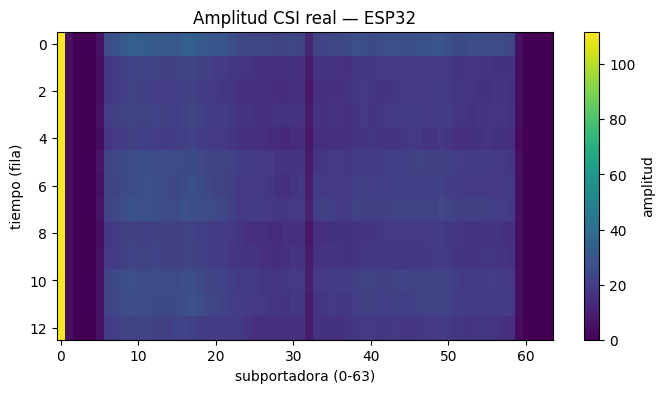

In [5]:
import matplotlib.pyplot as plt

X = cargar_amplitudes("data/example_csi.csv")

plt.figure(figsize=(8, 4))
plt.imshow(X, aspect="auto", cmap="viridis")
plt.xlabel("subportadora (0-63)")
plt.ylabel("tiempo (fila)")
plt.title("Amplitud CSI real — ESP32")
plt.colorbar(label="amplitud")
plt.show()
